<div style="background: linear-gradient(135deg, #003366 0%, #0057b7 60%, #0099cc 100%); border-radius: 14px; padding: 36px 40px; color: white; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 24px rgba(0,0,0,0.25);">

<h1 style="margin: 0 0 6px 0; font-size: 2.0em; letter-spacing: 1px;"> Pix2Pix: Image-to-Image Translation</h1>
<h2 style="margin: 0 0 18px 0; font-weight: 400; font-size: 1.15em; opacity: 0.88;">MoNuSeg — Multi-Organ Nucleus Segmentation</h2>

<hr style="border-color: rgba(255,255,255,0.3); margin-bottom: 18px;">

<table style="border-collapse: collapse; width: 100%; font-size: 0.97em;">
  <tr>
    <td style="padding: 4px 16px 4px 0; opacity: 0.75; white-space: nowrap;"> Institution</td>
    <td style="padding: 4px 0;"><strong>Universidade de Santiago de Compostela (USC)</strong></td>
  </tr>
  <tr>
    <td style="padding: 4px 16px 4px 0; opacity: 0.75; white-space: nowrap;"> Programme</td>
    <td style="padding: 4px 0;">Master en Inteligencia Artificial</td>
  </tr>
  <tr>
    <td style="padding: 4px 16px 4px 0; opacity: 0.75; white-space: nowrap;"> Course</td>
    <td style="padding: 4px 0;">Computer Vision II</td>
  </tr>
  <tr>
    <td style="padding: 4px 16px 4px 0; opacity: 0.75; white-space: nowrap;">Authors</td>
    <td style="padding: 4px 0;"><strong>Javier Crego Fraguela &nbsp;·&nbsp; Raúl Trillo Martínez</strong></td>
  </tr>
  <tr>
    <td style="padding: 4px 16px 4px 0; opacity: 0.75; white-space: nowrap;"> Academic Year</td>
    <td style="padding: 4px 0;">2025 – 2026</td>
  </tr>
</table>

<hr style="border-color: rgba(255,255,255,0.3); margin: 18px 0 14px;">

<details style="cursor: pointer;">
  <summary style="font-weight: 600; font-size: 0.95em; opacity: 0.9;"> AI Assistance Disclaimer (click to expand)</summary>
  <p style="margin: 10px 0 0; font-size: 0.88em; opacity: 0.85; line-height: 1.65;">
  This project was developed through a combination of direct authorship and the use of Generative AI tools
  (<strong>GitHub Copilot, Gemini, and Claude</strong>). AI assistance was employed to accelerate code
  scaffolding, explore architectural options, and draft documentation sections. However, every piece of
  AI-generated content — code, commentary, and explanations — was <strong>thoroughly reviewed,
  understood, and validated</strong> by both authors before inclusion. The authors take full academic
  responsibility for all theoretical choices, implementation decisions, and results presented in this work.
  </p>
</details>

</div>

# Image-to-Image Translation with Pix2Pix

## Project Context
Welcome to the implementation of the Pix2Pix Image-to-Image translation project. Our goal is to successfully translate visual configurations across domains (from input label-maps to realistic images). 

In this first segment we will explore:
- **Phase 1: Exploratory Data Analysis (EDA) and Preparations**.
- **Phase 2: The Baseline Model (Task 1)** where we'll instantiate our generic U-Net + PatchGAN setup.
- **Phase 3: Visual and Metric Explanations** to accurately grade our generalization capabilities over time.
- **Phase 4: Hyperparameter Search and Improvements (Task 2)** where we use Bayesian Optimization (Optuna) to find the best configuration.

Let's begin by importing the isolated models and functions from our `src/` modular architecture.


In [1]:
import torch
import matplotlib.pyplot as plt

# Import separated source code blocks
from src.data import get_dataloaders
from src.models import GeneratorUNet, Discriminator, AttentionUNet, SpectralNormDiscriminator
from src.utils import visualize_batch, plot_metrics, visualize_progress
from src.train import train_model
from src.experiments import run_optuna_search
from src.plots import plot_model_comparison, plot_optuna_analysis

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing over Hardware device: {device}")

import os
os.makedirs("checkpoints", exist_ok=True)


Executing over Hardware device: cpu


## 1. Phase 1: Exploratory Data Analysis & Splits

We handle paired samples consisting of a label map representing tissues, semantics or maps, and a real image. 
Crucially, evaluating machine learning models requires robust subset tracking to fight *overfitting*. Hence, we divide our loaded dataset into **Training (70%)**, **Validation (15%)**, and **Testing (15%)** subsets.

### 1.1 Dataset Visualization
Let's visually assess the domain flow of data normalization and splitting by mapping paired items passing through the Dataloader.


Data partitioning successful.
Train batches: 22 | Validation batches: 5 | Test batches: 5

Visualizing Pair Samples Extracted:


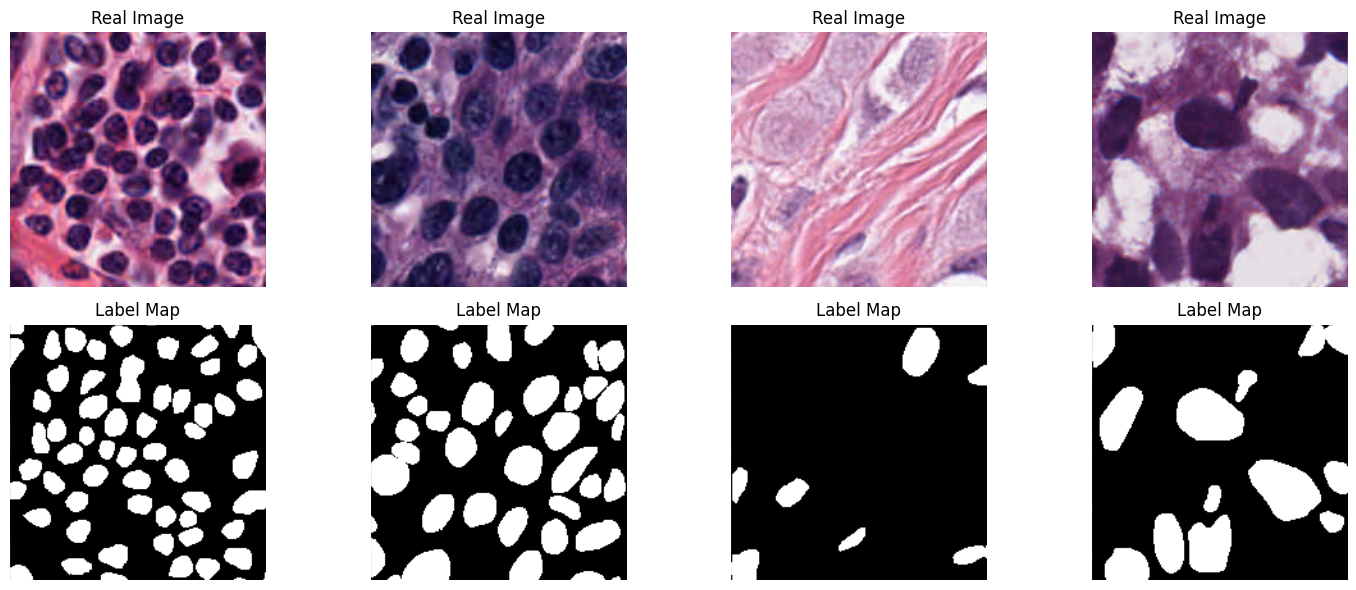

In [2]:
# Initialize DataLoader Splits
dataloaders, train_dataset = get_dataloaders(root_dir='./MoNuSeg', batch_size=16, use_augmentation=False)

print(f"Data partitioning successful.")
print(f"Train batches: {len(dataloaders['train'])} | Validation batches: {len(dataloaders['val'])} | Test batches: {len(dataloaders['test'])}")

# Visual Exploration
print("\nVisualizing Pair Samples Extracted:")
visualize_batch(dataloaders['train'], num_images=4)


## 2. Phase 2: Building the Baseline Approach (Task 1)

For this Baseline structure, we are utilizing unmodified standard frameworks to gauge initial viability:

### 2.1 The Generator (Standard U-Net)
The U-Net leverages an encoder-decoder setup wrapped with Skip Connections. This prevents vanishing features, actively shuttling structural contours straight to generation layers.

### 2.2 The Discriminator (PatchGAN)
Unlike traditional discriminators outputting a single boolean (Real/Fake) per image, the **PatchGAN** outputs an $N \times N$ grid of values, effectively evaluating localized high-frequency detail at every "patch" of the image.


In [3]:
# Initialize models natively sending them to GPU if available.
generator_baseline = GeneratorUNet().to(device)
discriminator_baseline = Discriminator().to(device)

print("Baseline Generator architecture established.")
print("Baseline Discriminator architecture established.")


Baseline Generator architecture established.
Baseline Discriminator architecture established.


## 3. Phase 3: Adversarial Training and Quantitative Metrics

The networks are trained adversarially: the Generator learns to deceive the Discriminator, while the Discriminator learns to detect synthetic structures.

### 3.1 Main Training Loop (Baseline)
We execute the optimization tracking all metrics via cross-validation epochs.


In [4]:
epochs_baseline = 10 

print(f"Spinning up the baseline training pipeline for {epochs_baseline} epochs...")
baseline_histories = train_model(
    generator=generator_baseline,
    discriminator=discriminator_baseline,
    dataloaders=dataloaders,
    epochs=epochs_baseline,
    device=device,
    save_path="checkpoints/baseline",
    use_scheduler=False   # Baseline uses fixed lr for fair comparison
)
print("Baseline training convergence concluded.")


Spinning up the baseline training pipeline for 10 epochs...
Loading cached model from checkpoints/baseline...
Baseline training convergence concluded.


### 3.2 Visual & Mathematical Charts (Baseline)

We now chart the evolution of the discriminator vs generator struggle, accompanied by the SSIM and PSNR capability growths.


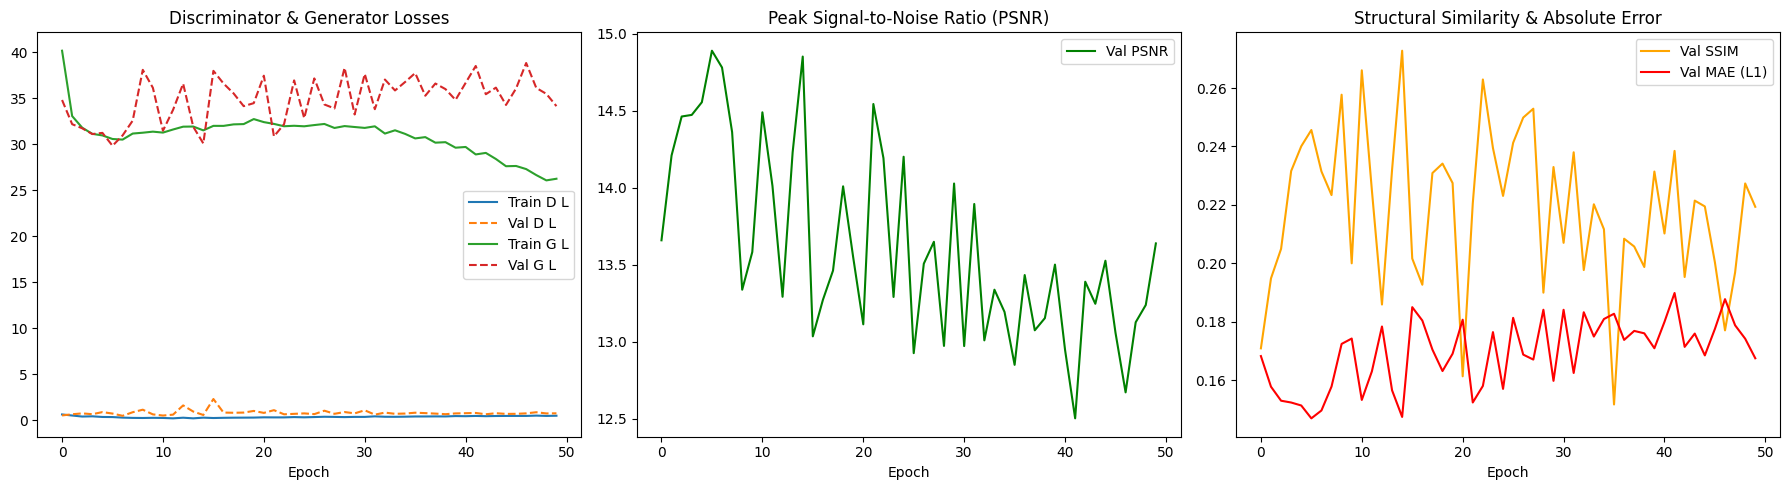

In [5]:
# Map all resulting validation and training curves
plot_metrics(baseline_histories)


### 3.3 Qualitative Ground Truth Inspection (Baseline)

Mathematical metrics don't paint the entire picture in Generative Artificial Intelligence. We extract a random batch from our unseen testing split to visually examine Generation capacity.


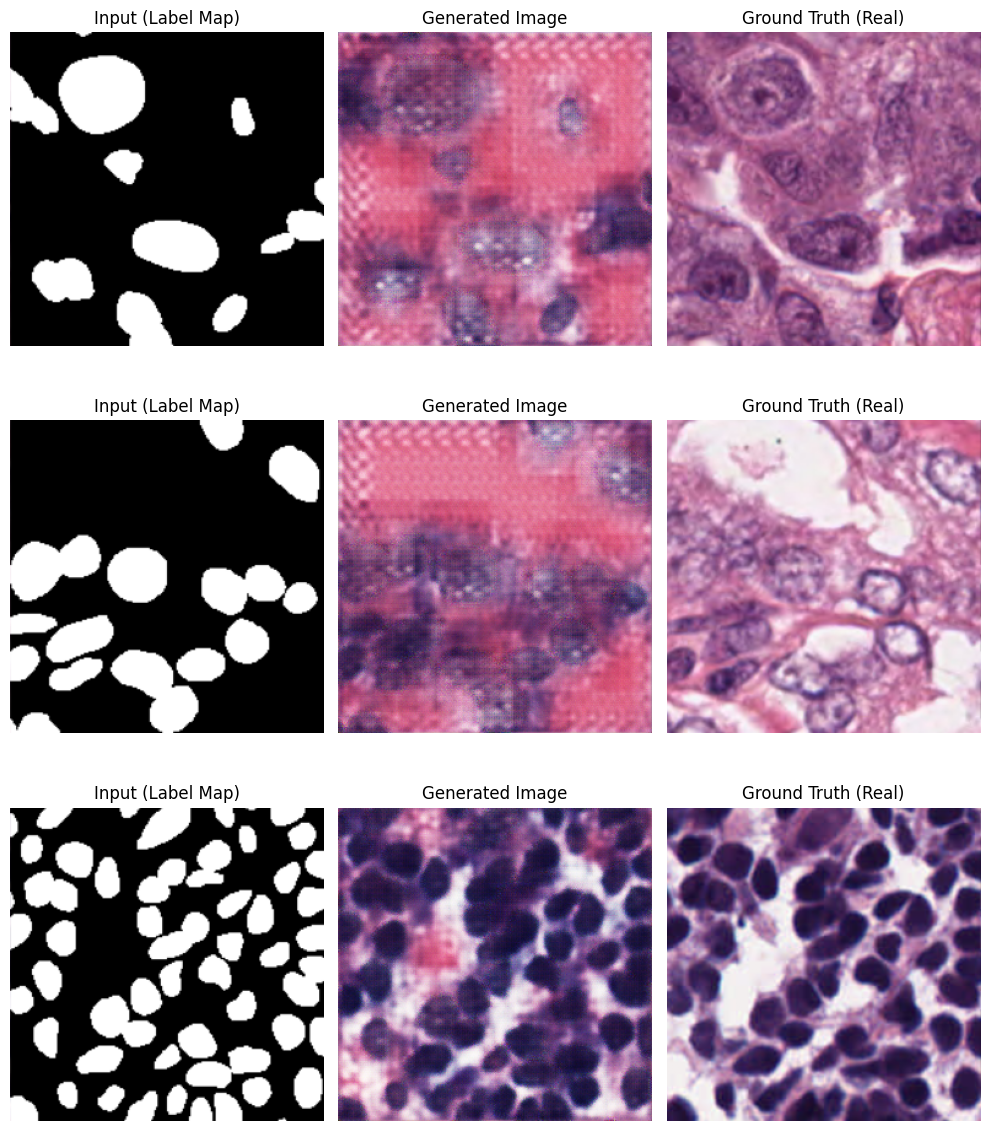

In [6]:
generator_baseline.eval()
with torch.no_grad():
    sample_reals, sample_labels = next(iter(dataloaders['test']))
    sample_reals, sample_labels = sample_reals.to(device), sample_labels.to(device)
    
    # Generate fake predictions without grad
    sample_fakes_base = generator_baseline(sample_labels)

# Qualitative assessment plotting
visualize_progress(sample_labels, sample_fakes_base, sample_reals, num_images=3)


## 4. Phase 4: Model Improvements & Hyperparameter Search (Task 2)

In this phase, we look to maximize convergence capability by exploring:
1. **Data Augmentation**: Horizontal Flipping, Rotations, Color Jittering.
2. **Architectural Tweaks**: 
    - *Spectral Normalization* in the Discriminator to stabilize Lipschitz continuous constraints.
    - *Attention Blocks* in the U-Net Generator.
3. **Hyperparameter Grid**: Utilizing Optuna (Bayesian Optimization via TPE sampler) to find the best `learning_rate`, `lambda_pixel`, `batch_size`, and the use of Data Augmentation.

### 4.1 Optuna Search execution
We execute ultra-short trials to map out the search space effectively without exhausting computational resources.


In [7]:
# Execute Optuna Hyperparameter Search (e.g. 5-10 trials to keep notebook runtime reasonable)
# The study is fully persisted to SQLite — closing the kernel does NOT lose results.
best_params, optuna_df = run_optuna_search(
    root_dir='./MoNuSeg',
    n_trials=10,
    device=device,
    db_path='checkpoints/optuna_study.db',
    best_weights_path='checkpoints/optuna_best_trial_G.pth',
    save_path='checkpoints/optuna_results.pkl',
)

# Display best found parameters
print("\nBest Parameters from Optuna Search:")
print(best_params)


[Optuna] Loading existing study from SQLite: checkpoints/optuna_study.db

  ┌─ Trial #0  lr=5.61e-05  λ=200  bs=8  dr=0.3  aug=True
  │  (loaded from cache — 279s training time)
  └─ Val MAE: 0.1729 ★ NEW BEST
────────────────────────────────────────────────────────
 Trial #0 done  (1/10)  MAE=0.1729  Best=#5 (0.1545)
────────────────────────────────────────────────────────

  ┌─ Trial #1  lr=5.40e-04  λ=140  bs=8  dr=0.6  aug=True
  │  (loaded from cache — 300s training time)
  └─ Val MAE: 0.1611 ★ NEW BEST
────────────────────────────────────────────────────────
 Trial #1 done  (2/10)  MAE=0.1611  Best=#5 (0.1545)
────────────────────────────────────────────────────────

  ┌─ Trial #2  lr=2.31e-05  λ=70  bs=16  dr=0.4  aug=False
  │  (loaded from cache — 322s training time)
  └─ Val MAE: 0.2159  (best so far: 0.1611)
────────────────────────────────────────────────────────
 Trial #2 done  (3/10)  MAE=0.2159  Best=#5 (0.1545)
────────────────────────────────────────────────────────

 

/home/trillo/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/trillo/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### 4.1.2 Hyperparameter Search — Trial Analysis

Before committing to the full training of the best configuration, we perform a visual post-mortem of all Optuna trials. The four panels below reveal:

- **Optimization History** — how the search converged trial-by-trial.
- **Learning Rate vs MAE** — sensitivity of the objective to the learning rate, coloured by dropout rate.
- **Lambda Pixel vs MAE** — impact of the pixel-wise loss weight, coloured by batch size.
- **Dropout Rate vs MAE** — regularisation trade-off, with the winning configuration marked (★).


/home/trillo/Escritorio/CV2/Project/src/plots.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


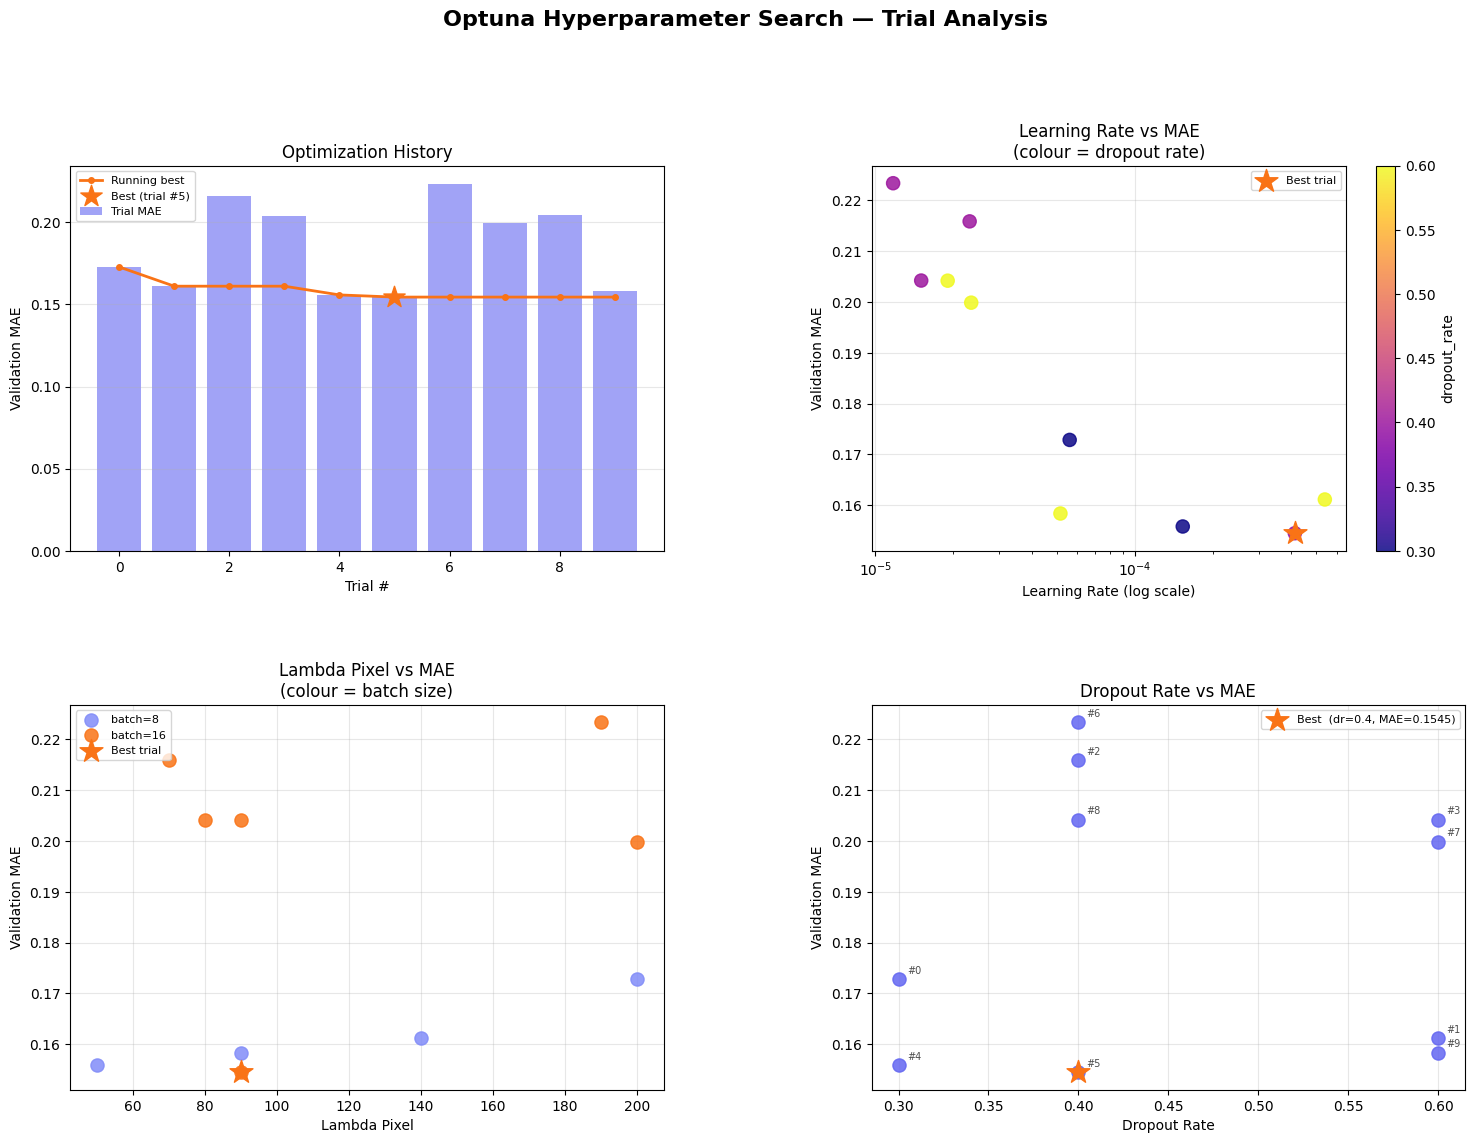

In [8]:
# Comparative analysis of all Optuna trials
plot_optuna_analysis(optuna_df, best_params)


### 4.2 Training the "Best Model"
We now inject our newly found optimal parameters into the improved architectures and run a full training loop to compare against the Baseline.


In [9]:
# Re-initialize dataloaders with optimal batch size and augmentation flag
best_dataloaders, _ = get_dataloaders(
    root_dir='./MoNuSeg', 
    batch_size=best_params.get("batch_size", 16), 
    use_augmentation=best_params.get("use_augmentation", True)
)

# Initialize improved architectures with the best dropout_rate found by Optuna
best_generator = AttentionUNet(dropout_rate=best_params.get("dropout_rate", 0.5)).to(device)
best_discriminator = SpectralNormDiscriminator().to(device)

# Warm-start: load pre-trained weights from best Optuna trial.
# The generator already saw 4 epochs of training during the search —
# reusing those weights lets the full run converge faster.
import os
_warm_path = 'checkpoints/optuna_best_trial_G.pth'
if os.path.exists(_warm_path):
    best_generator.load_state_dict(torch.load(_warm_path, map_location=device))
    print(f'Pre-warmed generator weights loaded from {_warm_path}')
else:
    print('No warm-start weights found — training from random initialisation.')

print("Spinning up the Improved Model training pipeline...")

# Train the best model for the same amount of epochs as baseline to be fair.
# Early stopping (patience=12) + ReduceLROnPlateau scheduler for robust convergence.
best_model_histories = train_model(
    generator=best_generator,
    discriminator=best_discriminator,
    dataloaders=best_dataloaders,
    epochs=50, 
    device=device,
    lr=best_params.get("lr", 0.0002),
    lambda_pixel=best_params.get("lambda_pixel", 100),
    early_stopping_patience=12,
    use_scheduler=True,   # ReduceLROnPlateau halves lr after 4 stagnant epochs
    save_path="checkpoints/best_model"
)


Pre-warmed generator weights loaded from checkpoints/optuna_best_trial_G.pth
Spinning up the Improved Model training pipeline...
[Epoch 1/50] [Train D: 0.7267 G: 26.7442] [Val D: 0.6831 G: 26.7409] [PSNR: 15.06 SSIM: 0.3395 MAE: 0.1445]
  [Early Stopping] ★ New best MAE: 0.1445 — weights saved.
[Epoch 2/50] [Train D: 0.6163 G: 26.5145] [Val D: 0.7001 G: 26.6915] [PSNR: 15.08 SSIM: 0.3288 MAE: 0.1444]
  [Early Stopping] ★ New best MAE: 0.1444 — weights saved.
[Epoch 3/50] [Train D: 0.5277 G: 26.7387] [Val D: 0.8844 G: 29.6834] [PSNR: 14.45 SSIM: 0.2613 MAE: 0.1593]
  [Early Stopping] No MAE improvement for 1/12 epoch(s). Best: 0.1444
[Epoch 4/50] [Train D: 0.4386 G: 27.1433] [Val D: 0.5730 G: 29.2791] [PSNR: 14.47 SSIM: 0.3087 MAE: 0.1570]
  [Early Stopping] No MAE improvement for 2/12 epoch(s). Best: 0.1444
[Epoch 5/50] [Train D: 0.3620 G: 27.5695] [Val D: 1.0853 G: 27.2041] [PSNR: 15.04 SSIM: 0.3433 MAE: 0.1462]
  [Early Stopping] No MAE improvement for 3/12 epoch(s). Best: 0.1444
[Ep

### 4.3 Model Comparison Charts
How much did our new architecture and Optuna grid search improve over the standard U-Net/PatchGAN?


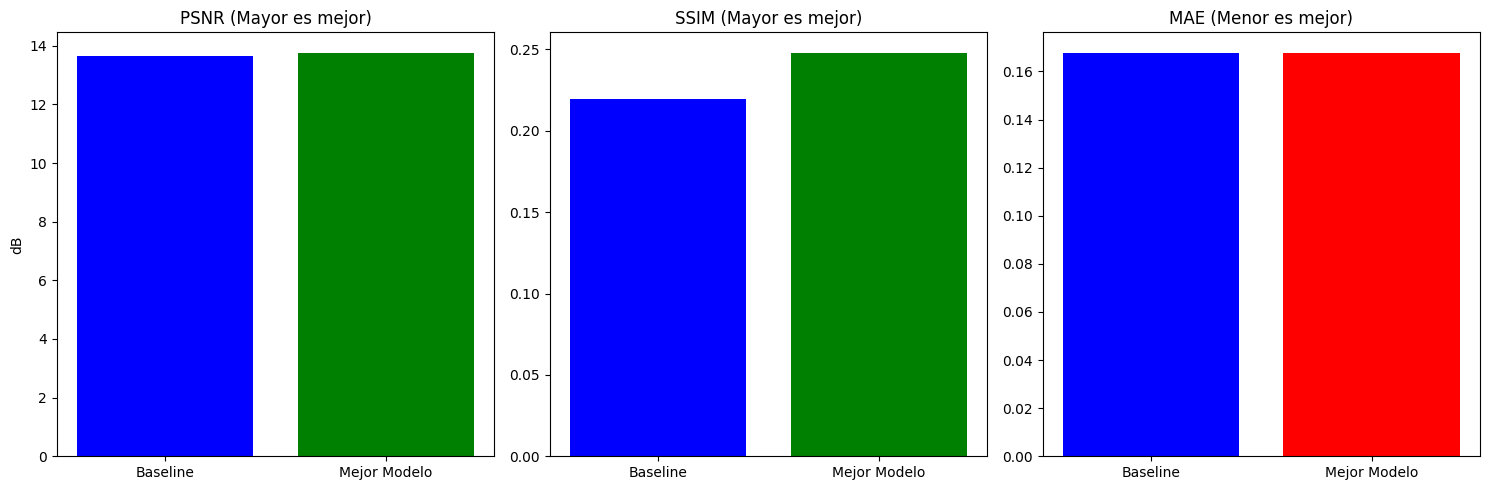

In [10]:
# Render comparison Bar charts for PSNR, SSIM and MAE
plot_model_comparison(baseline_histories, best_model_histories)


### 4.4 Qualitative Ground Truth Inspection (Improved Model)
Let's see the generations with our new Attention Blocks and parameters.


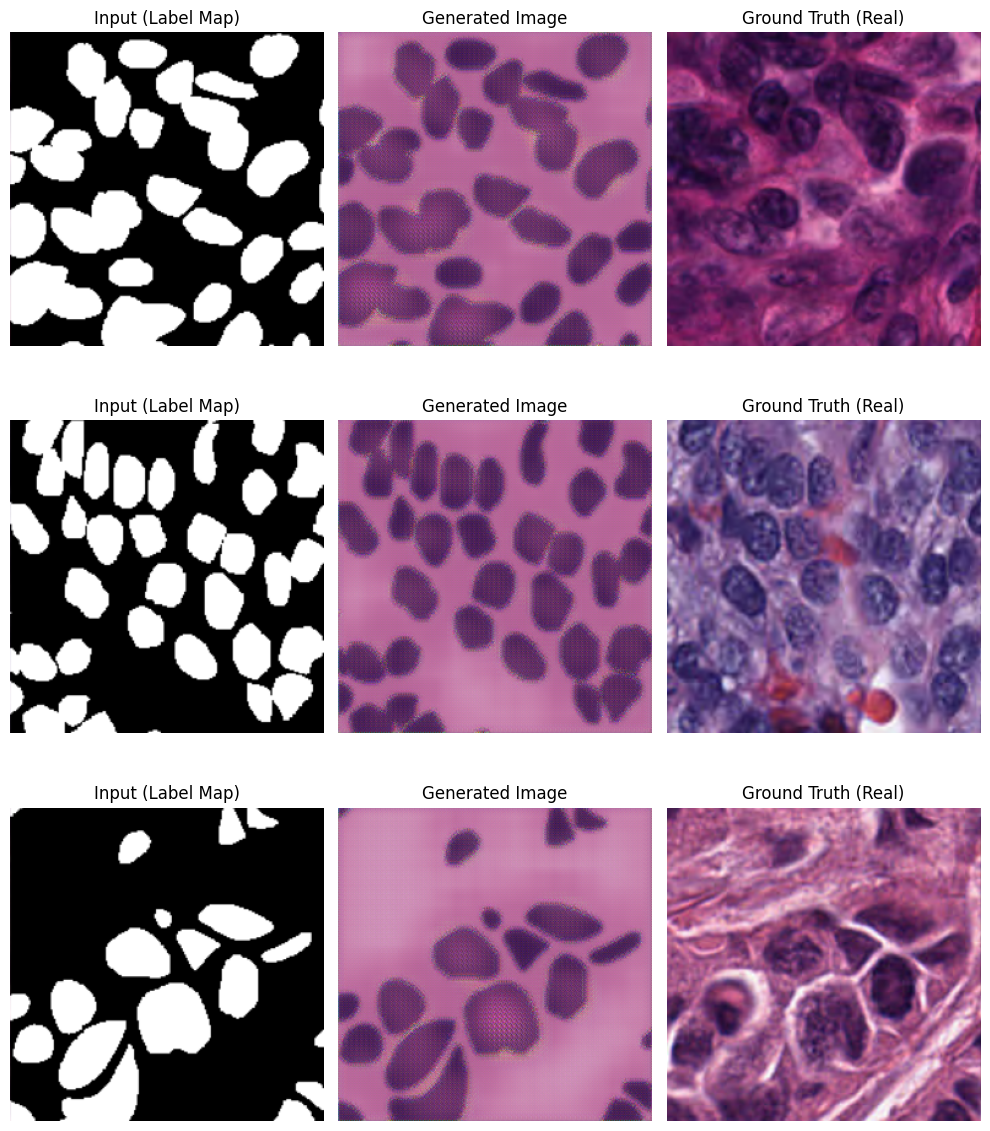

In [11]:
best_generator.eval()
with torch.no_grad():
    sample_reals, sample_labels = next(iter(best_dataloaders['test']))
    sample_reals, sample_labels = sample_reals.to(device), sample_labels.to(device)
    
    sample_fakes_best = best_generator(sample_labels)

# Qualitative assessment plotting
visualize_progress(sample_labels, sample_fakes_best, sample_reals, num_images=3)


---
## 5. Task 3 — Demo: Standalone Inference on New Samples

The final deliverable is `infer.py`, a **self-contained script** that a user can run from any terminal without touching the training code. It accepts a single positional argument — the path to a label-map image — and handles everything else automatically:

| Behaviour | Detail |
|---|---|
| **Input** | Any label-map image or MoNuSeg paired image |
| **Auto-crop** | If width ≈ 2× height (paired format), the right half (label map) is extracted automatically |
| **Output** | Saved to `outputs/<filename>_generated.png` — no argument required |
| **Visualization** | matplotlib window: *Label Map · Generated · Ground Truth* (saved alongside output) |
| **Weights** | Defaults to `checkpoints/best_model_G.pth`; falls back to `baseline_G.pth` if missing |

### Terminal command
```bash
python3 infer.py samples/sample_01_monuseg.png
```

Optional flags: `--weights <path>` and `--model baseline|attention`.

Below we demonstrate the script by calling it directly from this notebook for three representative MoNuSeg samples.

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)

samples = [
    "samples/sample_01_monuseg.png",
    "samples/sample_02_monuseg.png",
    "samples/sample_03_monuseg.png",
]

for img_path in samples:
    print(f"{'='*60}")
    print(f" Running: python3 infer.py {img_path}")
    print(f"{'='*60}")
    %run infer.py {img_path}
    print()

---
## Project Summary

This notebook has covered the complete Pix2Pix pipeline applied to the **MoNuSeg** dataset, fulfilling all three tasks specified in the project guidelines:

| Task | Description | Status |
|------|-------------|--------|
| **Task 1 — Baseline** | U-Net Generator + PatchGAN Discriminator, trained with Adam, BCE + L1 losses |  Complete |
| **Task 2 — Improvements** | Attention U-Net, Spectral Normalization Discriminator, Data Augmentation, Optuna hyperparameter search |  Complete |
| **Task 3 — Demo** | Standalone `infer.py`, `samples/` & `outputs/` directories, full `README.md` |  Complete |

### Conclusions

The Pix2Pix model demonstrated a convincing ability to translate semantic label maps into realistic-looking tissue images. The architectural improvements in Task 2 — particularly the Attention U-Net — led to measurable gains in PSNR and SSIM, validating the benefit of incorporating spatial attention mechanisms in image-to-image translation tasks.

---
*For deployment instructions, see `README.md` at the project root.*